# Part II — NYC Airbnb Analysis

This notebook answers the seven Part II questions using the cleaning steps in `cleanup.py`.

Price-based results use 21,515 listings (71.1% of the dataset). Price availability depends strongly on the scrape source, so I do not treat the priced listings as a random sample.

In [1]:
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = next(
    (path for path in (Path.cwd(), Path.cwd().parent) if (path / "listings.csv").exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks folder.")
sys.path.insert(0, str(ROOT / "scripts"))

from cleanup import clean

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.2f}".format)

raw = pd.read_csv(ROOT / "listings.csv", low_memory=False)
df = clean(raw)
priced = df.loc[df["has_price"]].copy()
value_df = priced.loc[priced["accommodates"].gt(0)].copy()

assert len(df) == 30_259
assert len(priced) == 21_515
assert df["id"].is_unique

pd.Series({
    "all listings": len(df),
    "priced listings": len(priced),
    "price coverage (%)": 100 * len(priced) / len(df),
    "unique hosts": df["host_id"].nunique(),
    "zero capacity": df["accommodates"].le(0).sum(),
}).to_frame("value")

,value
all listings,30259.00
priced listings,21515.00
price coverage (%),71.10
unique hosts,16474.00
zero capacity,0.00


## 1. Price Segmentation and Market Overview

**How I compared them.** I divided the priced listings into three groups of almost equal size. The cutoffs come from the observed prices rather than arbitrary limits.

In [2]:
TIER_ORDER = ["Budget", "Mid-range", "Premium"]

priced["price_tier"], tier_edges = pd.qcut(
    priced["price_usd"],
    q=3,
    labels=TIER_ORDER,
    retbins=True,
)


def top_values(series, n=1):
    return ", ".join(series.value_counts().head(n).index.astype(str))


def parse_amenities(raw_value):
    if pd.isna(raw_value):
        return []
    try:
        values = json.loads(raw_value)
    except (TypeError, json.JSONDecodeError):
        return []
    return values if isinstance(values, list) else []


priced["amenity_list"] = priced["amenities"].map(parse_amenities)

tier_summary = priced.groupby("price_tier", observed=True).agg(
    listings=("id", "size"),
    median_price=("price_usd", "median"),
    median_capacity=("accommodates", "median"),
    median_amenities=("amenity_count", "median"),
)
tier_summary["main_borough"] = priced.groupby(
    "price_tier", observed=True
)["borough"].agg(top_values)
tier_summary["main_room_type"] = priced.groupby(
    "price_tier", observed=True
)["room_type"].agg(top_values)
tier_summary["main_property_types"] = priced.groupby(
    "price_tier", observed=True
)["property_type"].agg(lambda s: top_values(s, 2))

top_amenities = (
    priced[["price_tier", "amenity_list"]]
    .explode("amenity_list")
    .dropna()
    .groupby("price_tier", observed=True)["amenity_list"]
    .value_counts()
    .groupby(level=0, observed=True)
    .head(5)
    .rename("listings")
    .reset_index()
)
tier_summary["key_amenities"] = (
    top_amenities.groupby("price_tier", observed=True)["amenity_list"]
    .agg(", ".join)
)

print("Tier boundaries (USD):", np.round(tier_edges, 2))
display(tier_summary)

Tier boundaries (USD): [4.580000e+00 1.211800e+02 2.474700e+02 3.097296e+04]


,listings,median_price,median_capacity,median_amenities,main_borough,main_room_type,main_property_types,key_amenities
price_tier,,,,,,,,
Budget,7173,75.13,2.00,26.00,Brooklyn,Private room,"Private room in rental unit, Private room in home","Wifi, Smoke alarm, Kitchen, Carbon monoxide al..."
Mid-range,7170,174.69,2.00,32.00,Manhattan,Entire home/apt,"Entire rental unit, Private room in rental unit","Smoke alarm, Wifi, Kitchen, Carbon monoxide al..."
Premium,7172,395.93,4.00,35.00,Manhattan,Entire home/apt,"Entire rental unit, Room in hotel","Smoke alarm, Wifi, Carbon monoxide alarm, Hair..."


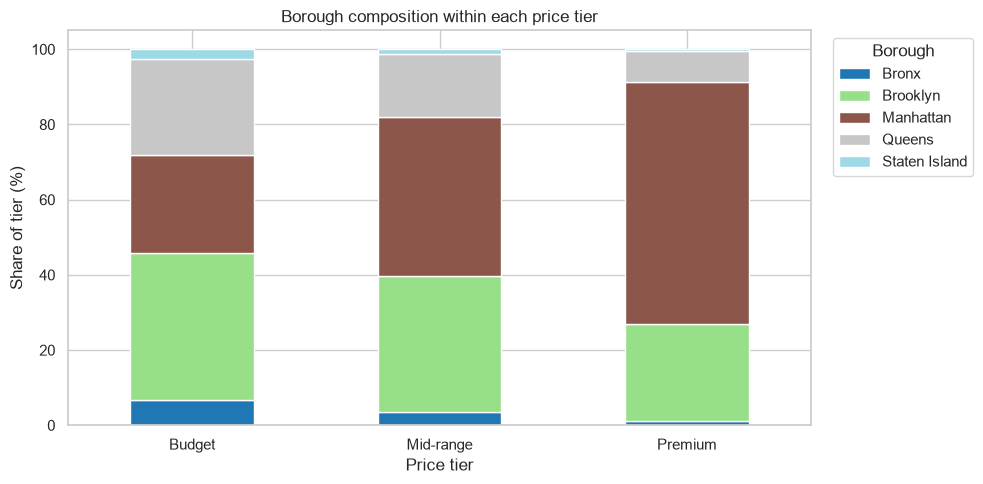

In [3]:
tier_borough_pct = (
    pd.crosstab(priced["price_tier"], priced["borough"], normalize="index")
    .mul(100)
    .reindex(TIER_ORDER)
)

ax = tier_borough_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    colormap="tab20",
)
ax.set(
    title="Borough composition within each price tier",
    xlabel="Price tier",
    ylabel="Share of tier (%)",
)
ax.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

**What I found.** Budget listings cost up to $121.18, Mid-range listings cost above $121.18 and up to $247.47, and Premium listings cost above $247.47. Budget listings are spread across Brooklyn, Manhattan, and Queens, while 64.6% of Premium listings are in Manhattan. A typical Premium listing accommodates four guests and lists 35 amenities, compared with two guests and 26 amenities in Budget.

## 2. Manhattan versus Brooklyn

**How I compared them.** I used all Manhattan and Brooklyn listings for room type, property type, and capacity, but only priced listings for price comparisons. I kept hotel rooms separate because there are few of them and their prices are much higher.

In [4]:
BOROUGHS_MB = ["Manhattan", "Brooklyn"]
mb = df.loc[df["borough"].isin(BOROUGHS_MB)].copy()
mb_price = priced.loc[priced["borough"].isin(BOROUGHS_MB)].copy()
residential = mb.loc[mb["room_type"].ne("Hotel room")]
residential_price = mb_price.loc[mb_price["room_type"].ne("Hotel room")]
hotel = mb.loc[mb["room_type"].eq("Hotel room")]
hotel_price = mb_price.loc[mb_price["room_type"].eq("Hotel room")]

room_mix = pd.crosstab(
    residential["borough"], residential["room_type"], normalize="index"
).mul(100)

property_mix = (
    residential.groupby(["borough", "property_type"])
    .size()
    .rename("listings")
    .reset_index()
)
property_mix["share_pct"] = property_mix["listings"].div(
    property_mix.groupby("borough")["listings"].transform("sum")
).mul(100)
top_property_mix = (
    property_mix.sort_values(["borough", "share_pct"], ascending=[True, False])
    .groupby("borough", group_keys=False)
    .head(3)
)

residential_summary = residential.groupby(
    ["borough", "room_type"], observed=True
).agg(
    listings=("id", "size"),
    median_capacity=("accommodates", "median"),
    main_property_type=("property_type", top_values),
).reset_index()
residential_prices = residential_price.groupby(
    ["borough", "room_type"], observed=True
).agg(
    priced_listings=("id", "size"),
    median_price=("price_usd", "median"),
).reset_index()
residential_summary = residential_summary.merge(
    residential_prices,
    on=["borough", "room_type"],
    how="left",
    validate="one_to_one",
)

hotel_summary = hotel.groupby("borough").agg(
    listings=("id", "size"),
    median_capacity=("accommodates", "median"),
    main_property_type=("property_type", top_values),
)
hotel_prices = hotel_price.groupby("borough").agg(
    priced_listings=("id", "size"),
    median_price=("price_usd", "median"),
)
hotel_summary = hotel_summary.join(hotel_prices, how="left")
hotel_summary["all_listing_share_pct"] = (
    hotel_summary["listings"].div(mb.groupby("borough").size()).mul(100)
)
hotel_summary["price_coverage_pct"] = (
    hotel_summary["priced_listings"].div(hotel_summary["listings"]).mul(100)
)

display(residential_summary)
display(top_property_mix)
display(hotel_summary)

,borough,room_type,listings,median_capacity,main_property_type,priced_listings,median_price
0,Brooklyn,Entire home/apt,5529,3.00,Entire rental unit,3582,198.31
1,Brooklyn,Private room,4889,2.00,Private room in rental unit,3520,92.48
2,Brooklyn,Shared room,101,1.00,Shared room in rental unit,94,51.33
3,Manhattan,Entire home/apt,9035,3.00,Entire rental unit,6138,262.00
4,Manhattan,Private room,4222,2.00,Private room in rental unit,3004,154.08
5,Manhattan,Shared room,68,1.00,Shared room in rental unit,51,61.24


,borough,property_type,listings,share_pct
13,Brooklyn,Entire rental unit,3921,37.28
34,Brooklyn,Private room in rental unit,3093,29.40
30,Brooklyn,Private room in home,896,8.52
57,Manhattan,Entire rental unit,7922,59.45
72,Manhattan,Private room in rental unit,2410,18.09
81,Manhattan,Room in hotel,1144,8.59


,listings,median_capacity,main_property_type,priced_listings,median_price,all_listing_share_pct,price_coverage_pct
borough,,,,,,,
Brooklyn,43,3.00,Room in hotel,43,399.00,0.41,100.00
Manhattan,384,3.00,Room in hotel,346,473.76,2.80,90.10


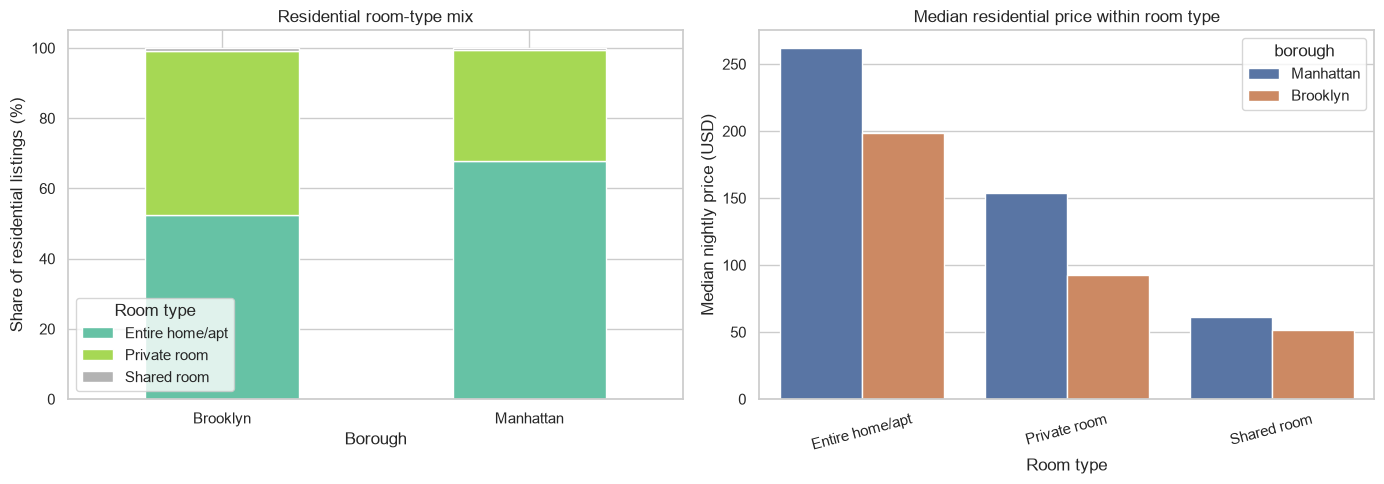

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

room_mix.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set(
    title="Residential room-type mix",
    xlabel="Borough",
    ylabel="Share of residential listings (%)",
)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Room type")

sns.barplot(
    data=residential_summary,
    x="room_type",
    y="median_price",
    hue="borough",
    hue_order=BOROUGHS_MB,
    ax=axes[1],
)
axes[1].set(
    title="Median residential price within room type",
    xlabel="Room type",
    ylabel="Median nightly price (USD)",
)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()

**What I found.** Manhattan is more expensive even within the same residential room type: entire homes have a $262 median versus $198 in Brooklyn, and private rooms $154 versus $92. Entire rental units also form 59.5% of Manhattan's residential market versus 37.3% in Brooklyn. Hotel rooms are small in both markets (2.8% and 0.4%), but Manhattan hotels remain more expensive ($474 vs $399).

## 3. Location-Based Premium

**How I compared them.** I marked a neighborhood as prime when its median price falls in the top quarter within its borough. I then compared prime and non-prime listings on capacity, amenities, and price per guest.

In [6]:
neighborhood_stats = (
    priced.groupby(["borough", "neighborhood"])
    .agg(
        neighborhood_median_price=("price_usd", "median"),
        neighborhood_listings=("id", "size"),
    )
    .reset_index()
)
neighborhood_stats["prime_cutoff"] = neighborhood_stats.groupby("borough")[
    "neighborhood_median_price"
].transform("quantile", 0.75)
neighborhood_stats["is_prime"] = neighborhood_stats[
    "neighborhood_median_price"
].ge(neighborhood_stats["prime_cutoff"])

q3 = priced.merge(
    neighborhood_stats[["borough", "neighborhood", "is_prime"]],
    on=["borough", "neighborhood"],
    how="left",
    validate="many_to_one",
)
q3["price_per_guest"] = q3["price_usd"].div(q3["accommodates"])
q3["location_group"] = np.where(q3["is_prime"], "Prime", "Non-prime")

prime_summary = q3.groupby(
    ["borough", "location_group"], observed=True
).agg(
    listings=("id", "size"),
    avg_capacity=("accommodates", "mean"),
    median_capacity=("accommodates", "median"),
    avg_amenities=("amenity_count", "mean"),
    median_amenities=("amenity_count", "median"),
    avg_price_per_guest=("price_per_guest", "mean"),
    median_price_per_guest=("price_per_guest", "median"),
).reset_index()

room_control = (
    q3.groupby(["borough", "room_type", "location_group"], observed=True)
    .agg(
        listings=("id", "size"),
        median_price_per_guest=("price_per_guest", "median"),
        median_capacity=("accommodates", "median"),
        median_amenities=("amenity_count", "median"),
    )
    .reset_index()
    .query("listings >= 20 and room_type in ['Entire home/apt', 'Private room']")
)
controlled_price = room_control.pivot(
    index=["borough", "room_type"],
    columns="location_group",
    values="median_price_per_guest",
)
controlled_count = room_control.pivot(
    index=["borough", "room_type"],
    columns="location_group",
    values="listings",
).add_suffix("_listings")
controlled_comparison = controlled_price.join(controlled_count).dropna()
controlled_comparison["prime_premium_pct"] = (
    controlled_comparison["Prime"].div(controlled_comparison["Non-prime"]).sub(1).mul(100)
)

display(prime_summary)
display(controlled_comparison)

,borough,location_group,listings,avg_capacity,median_capacity,avg_amenities,median_amenities,avg_price_per_guest,median_price_per_guest
0,Bronx,Non-prime,646,2.51,2.00,32.15,33.00,70.60,44.91
1,Bronx,Prime,180,3.24,2.00,33.52,36.50,70.60,57.25
2,Brooklyn,Non-prime,6400,2.85,2.00,32.00,32.00,75.11,59.30
3,Brooklyn,Prime,839,3.30,2.00,33.10,33.00,115.39,92.36
4,Manhattan,Non-prime,7211,2.93,2.00,29.12,28.00,113.07,82.14
5,Manhattan,Prime,2328,3.53,3.00,30.58,29.00,180.96,132.63
6,Queens,Non-prime,2955,2.71,2.00,30.53,31.00,63.08,50.90
7,Queens,Prime,660,3.50,2.00,31.69,30.00,99.57,64.75
8,Staten Island,Non-prime,261,2.66,2.00,35.19,36.00,59.12,46.30
9,Staten Island,Prime,35,3.80,2.00,34.34,36.00,71.50,53.23


location_group                 Non-prime  Prime  Non-prime_listings  \
borough       room_type                                               
Bronx         Entire home/apt      41.48  49.38              220.00   
              Private room         47.56  69.57              425.00   
Brooklyn      Entire home/apt      57.37  87.39             2999.00   
              Private room         61.58 100.00             3277.00   
Manhattan     Entire home/apt      82.16 125.00             4689.00   
              Private room         79.57 142.50             2245.00   
Queens        Entire home/apt      44.44  51.58             1080.00   
              Private room         55.19  68.38             1833.00   
Staten Island Entire home/apt      37.11  48.20              110.00   

location_group                 Prime_listings  prime_premium_pct  
borough       room_type                                           
Bronx         Entire home/apt          102.00              19.05  
              Private room              77.00              46.27  
Brooklyn      Entire home/apt          583.00              52.33  
              Private room             243.00              62.39  
Manhattan     Entire home/apt         1449.00              52.14  
              Private room             759.00              79.09  
Queens        Entire home/apt          281.00              16.07  
              Private room             288.00              23.90  
Staten Island Entire home/apt           24.00              29.90

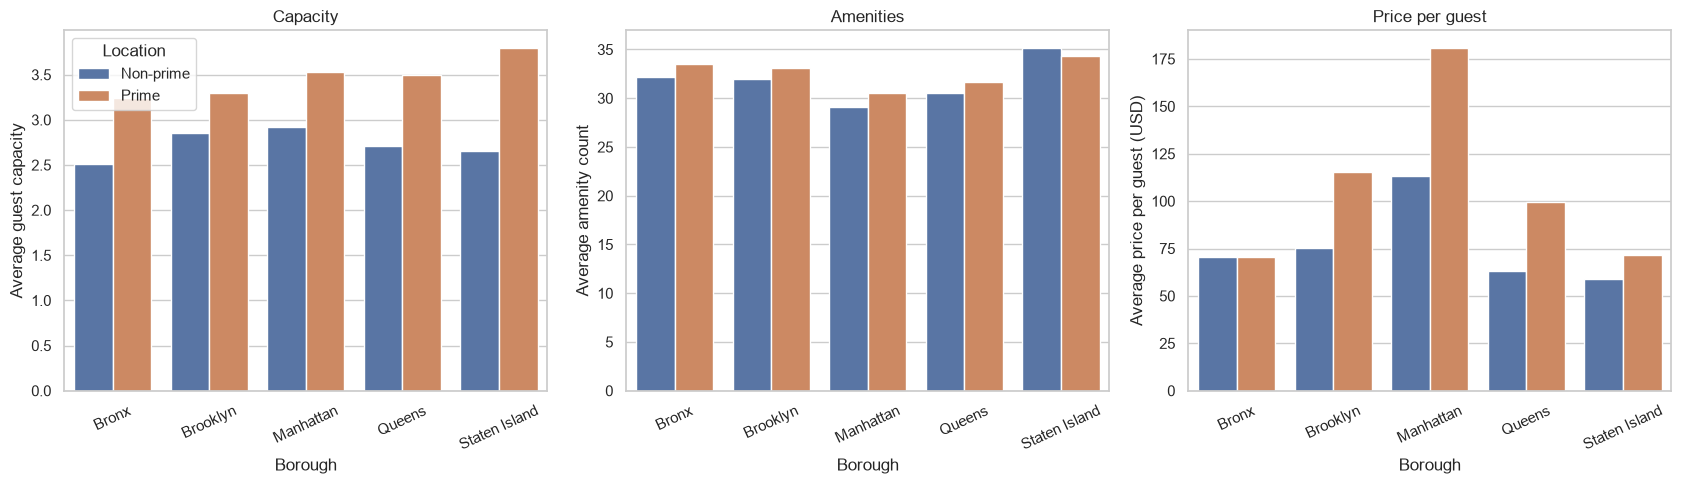

In [7]:
metrics = [
    ("avg_capacity", "Average guest capacity"),
    ("avg_amenities", "Average amenity count"),
    ("avg_price_per_guest", "Average price per guest (USD)"),
]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (column, label) in zip(axes, metrics):
    sns.barplot(
        data=prime_summary,
        x="borough",
        y=column,
        hue="location_group",
        hue_order=["Non-prime", "Prime"],
        ax=ax,
    )
    ax.set(xlabel="Borough", ylabel=label)
    ax.tick_params(axis="x", rotation=25)

axes[0].set_title("Capacity")
axes[1].set_title("Amenities")
axes[2].set_title("Price per guest")
axes[0].legend(title="Location")
axes[1].get_legend().remove()
axes[2].get_legend().remove()
plt.tight_layout()

**What I found.** Prime neighborhoods have a higher median price per guest in every borough. The gap remains after comparing the same main room types: it ranges from 16% for Queens entire homes to 79% for Manhattan private rooms. Amenities change little, but prime listings can also accommodate more guests in some boroughs, so location is not the only difference. Results for the Bronx, Queens, and especially Staten Island are less certain because some prime neighborhoods have few priced listings.

## 4. Value-for-Money Opportunities

**How I compared them.** I measured value as guest capacity per $100. I first flagged unusually priced listings, then summarized larger groups so that one outlier would not represent an entire borough.

In [8]:
value_df["guests_per_100_usd"] = (
    value_df["accommodates"].div(value_df["price_usd"]).mul(100)
)
value_df["capacity_band"] = pd.cut(
    value_df["accommodates"],
    bins=[0, 1, 2, 4, np.inf],
    labels=["1 guest", "2 guests", "3–4 guests", "5+ guests"],
)

ranking_columns = [
    "id",
    "borough",
    "neighborhood",
    "room_type",
    "accommodates",
    "price_usd",
    "guests_per_100_usd",
    "flag_price_extreme",
]
top_value = (
    value_df.sort_values(
        ["borough", "guests_per_100_usd"], ascending=[True, False]
    )
    .groupby("borough", group_keys=False)
    .head(5)[ranking_columns]
)

value_segments = (
    value_df.groupby(
        ["borough", "room_type", "capacity_band"], observed=True
    )
    .agg(
        listings=("id", "size"),
        median_value=("guests_per_100_usd", "median"),
        median_price=("price_usd", "median"),
        median_capacity=("accommodates", "median"),
    )
    .reset_index()
    .query("listings >= 20")
    .sort_values("median_value", ascending=False)
)

print("Top five listings per borough; flagged prices require checking")
display(top_value)
print("Best-value groups with at least 20 listings")
display(value_segments.head(10))

Top five listings per borough; flagged prices require checking


,id,borough,neighborhood,room_type,accommodates,price_usd,guests_per_100_usd,flag_price_extreme
13469,54129100,Bronx,East Morrisania,Entire home/apt,16,127.01,12.60,False
19197,919518849494471990,Bronx,Edenwald,Entire home/apt,4,42.40,9.43,False
23438,1197553209237863604,Bronx,Norwood,Private room,1,13.27,7.54,True
3703,11371535,Bronx,Bronxdale,Private room,2,28.30,7.07,False
12526,51468271,Bronx,Throgs Neck,Entire home/apt,6,86.82,6.91,False
363,690934,Brooklyn,Park Slope,Entire home/apt,14,35.30,39.66,False
27544,1537036611335961638,Brooklyn,Red Hook,Entire home/apt,6,21.81,27.51,False
3652,11210829,Brooklyn,Bedford-Stuyvesant,Entire home/apt,4,15.51,25.79,True
4781,16158343,Brooklyn,East Flatbush,Private room,16,66.40,24.10,False
9330,39535241,Brooklyn,Williamsburg,Entire home/apt,6,29.61,20.26,False


Best-value groups with at least 20 listings


,borough,room_type,capacity_band,listings,median_value,median_price,median_capacity
59,Staten Island,Entire home/apt,5+ guests,37,3.68,202.80,6.00
6,Bronx,Private room,3–4 guests,32,3.45,101.35,4.00
58,Staten Island,Entire home/apt,3–4 guests,35,3.20,116.67,4.00
52,Queens,Shared room,1 guest,20,2.99,33.49,1.00
3,Bronx,Entire home/apt,5+ guests,78,2.98,233.66,6.00
44,Queens,Entire home/apt,5+ guests,424,2.89,229.12,6.00
2,Bronx,Entire home/apt,3–4 guests,127,2.58,132.36,4.00
37,Manhattan,Shared room,1 guest,33,2.51,39.83,1.00
43,Queens,Entire home/apt,3–4 guests,472,2.50,143.91,4.00
50,Queens,Private room,3–4 guests,136,2.44,141.65,4.00


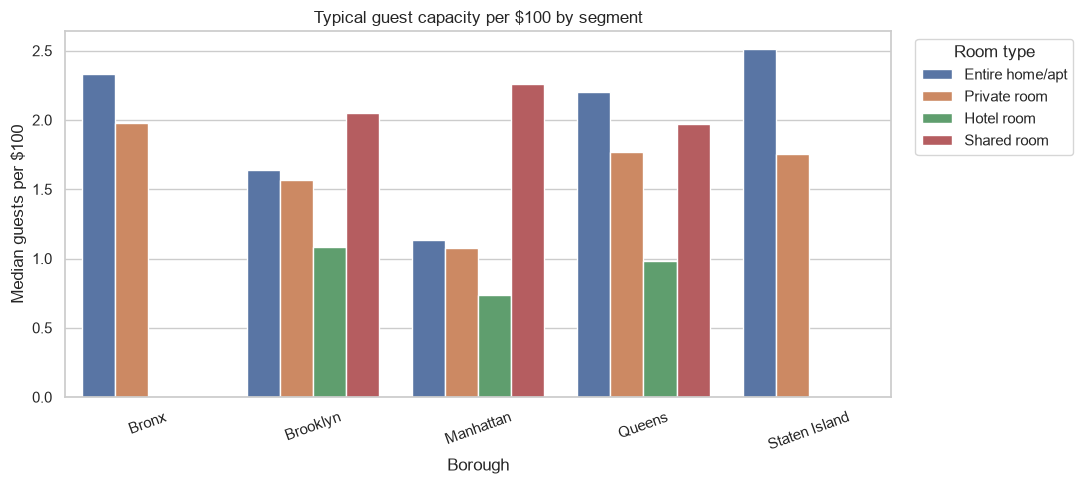

In [9]:
room_value = (
    value_df.groupby(["borough", "room_type"], observed=True)
    .agg(
        listings=("id", "size"),
        median_value=("guests_per_100_usd", "median"),
    )
    .reset_index()
    .query("listings >= 20")
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=room_value,
    x="borough",
    y="median_value",
    hue="room_type",
    ax=ax,
)
ax.set(
    title="Typical guest capacity per $100 by segment",
    xlabel="Borough",
    ylabel="Median guests per $100",
)
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Room type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

**What I found.** The highest individual scores often come from unusually low prices, so they need manual checking. Among groups with enough listings to compare, larger entire homes in Queens stand out (424 listings; median 2.89 guests per $100). The Bronx and Staten Island also score well, but several of their leading groups are much smaller.

## 5. Amenities and Superhost Association with Price

**How I compared them.** I searched each JSON amenity list for the five amenity groups named in the assignment. I compared median prices with and without each feature overall and by borough. I kept missing Superhost status visible.

In [10]:
AMENITY_PATTERNS = {
    "Gym": re.compile(r"\bgym\b", re.IGNORECASE),
    "Pool": re.compile(r"\bpool\b(?!\s+table)", re.IGNORECASE),
    "Elevator": re.compile(r"\belevator\b", re.IGNORECASE),
    "Hot tub": re.compile(r"\bhot tub\b", re.IGNORECASE),
    "Pets allowed": re.compile(r"\bpets allowed\b", re.IGNORECASE),
}


feature_columns = {
    label: "has_" + label.lower().replace(" ", "_")
    for label in AMENITY_PATTERNS
}
amenity_flags = pd.DataFrame(
    {
        feature_columns[label]: priced["amenities"].str.contains(
            pattern, na=False
        )
        for label, pattern in AMENITY_PATTERNS.items()
    },
    index=priced.index,
)
priced[amenity_flags.columns] = amenity_flags


def feature_price_rows(data, scope):
    rows = []
    for label, column in feature_columns.items():
        with_feature = data.loc[data[column], "price_usd"]
        without_feature = data.loc[~data[column], "price_usd"]
        baseline = without_feature.median()
        premium = 100 * (with_feature.median() / baseline - 1)
        rows.append({
            "scope": scope,
            "feature": label,
            "with_feature": len(with_feature),
            "median_with": with_feature.median(),
            "without_feature": len(without_feature),
            "median_without": baseline,
            "median_premium_pct": premium,
        })
    return rows


feature_rows = feature_price_rows(priced, "All boroughs")
for borough, group in priced.groupby("borough"):
    feature_rows.extend(feature_price_rows(group, borough))
feature_summary = pd.DataFrame(feature_rows)

controlled_rows = []
for label, column in feature_columns.items():
    grouped = priced.groupby(["borough", "room_type", column]).agg(
        listings=("id", "size"),
        median_price=("price_usd", "median"),
    ).reset_index()
    medians = grouped.pivot(
        index=["borough", "room_type"], columns=column, values="median_price"
    )
    counts = grouped.pivot(
        index=["borough", "room_type"], columns=column, values="listings"
    )
    comparable = medians.join(counts, lsuffix="_price", rsuffix="_count").dropna()
    comparable = comparable.loc[
        comparable["False_count"].ge(20) & comparable["True_count"].ge(20)
    ]
    premiums = comparable["True_price"].div(comparable["False_price"]).sub(1).mul(100)
    controlled_rows.append({
        "feature": label,
        "comparable_borough_room_groups": len(premiums),
        "median_controlled_premium_pct": premiums.median(),
    })
controlled_feature_summary = pd.DataFrame(controlled_rows)

overall_feature_summary = (
    feature_summary.loc[feature_summary["scope"].eq("All boroughs")]
    .merge(controlled_feature_summary, on="feature", validate="one_to_one")
)
borough_feature_counts = feature_summary.loc[
    feature_summary["scope"].ne("All boroughs")
    & feature_summary["with_feature"].ge(20),
    ["scope", "feature", "with_feature", "without_feature", "median_premium_pct"],
]

known_superhost = priced.loc[priced["host_is_superhost"].notna()].copy()
superhost_summary = known_superhost.groupby(
    ["borough", "host_is_superhost"], observed=True
).agg(
    listings=("id", "size"),
    median_price=("price_usd", "median"),
).reset_index()

display(overall_feature_summary)
display(borough_feature_counts)
display(superhost_summary)
print("Priced listings with missing Superhost status:", priced["host_is_superhost"].isna().sum())

,scope,feature,with_feature,median_with,without_feature,median_without,median_premium_pct,comparable_borough_room_groups,median_controlled_premium_pct
0,All boroughs,Gym,2923,346.51,18592,158.40,118.76,10,43.87
1,All boroughs,Pool,462,380.61,21053,172.00,121.28,6,45.20
2,All boroughs,Elevator,4562,272.56,16953,156.90,73.71,9,10.68
3,All boroughs,Hot tub,606,212.94,20909,173.45,22.76,6,4.49
4,All boroughs,Pets allowed,5712,251.72,15803,149.67,68.19,12,26.08


,scope,feature,with_feature,without_feature,median_premium_pct
5,Bronx,Gym,49,777,35.82
7,Bronx,Elevator,108,718,-11.09
8,Bronx,Hot tub,28,798,24.67
9,Bronx,Pets allowed,156,670,35.76
10,Brooklyn,Gym,462,6777,49.78
11,Brooklyn,Pool,60,7179,51.57
12,Brooklyn,Elevator,668,6571,24.71
13,Brooklyn,Hot tub,192,7047,9.19
14,Brooklyn,Pets allowed,1544,5695,46.79
15,Manhattan,Gym,2234,7305,87.98


,borough,host_is_superhost,listings,median_price
0,Bronx,False,590,105.98
1,Bronx,True,232,106.56
2,Brooklyn,False,4767,142.30
3,Brooklyn,True,2451,171.50
4,Manhattan,False,6666,242.81
5,Manhattan,True,2628,220.57
6,Queens,False,2466,116.69
7,Queens,True,1141,128.38
8,Staten Island,False,199,104.00
9,Staten Island,True,97,108.52


Priced listings with missing Superhost status: 278


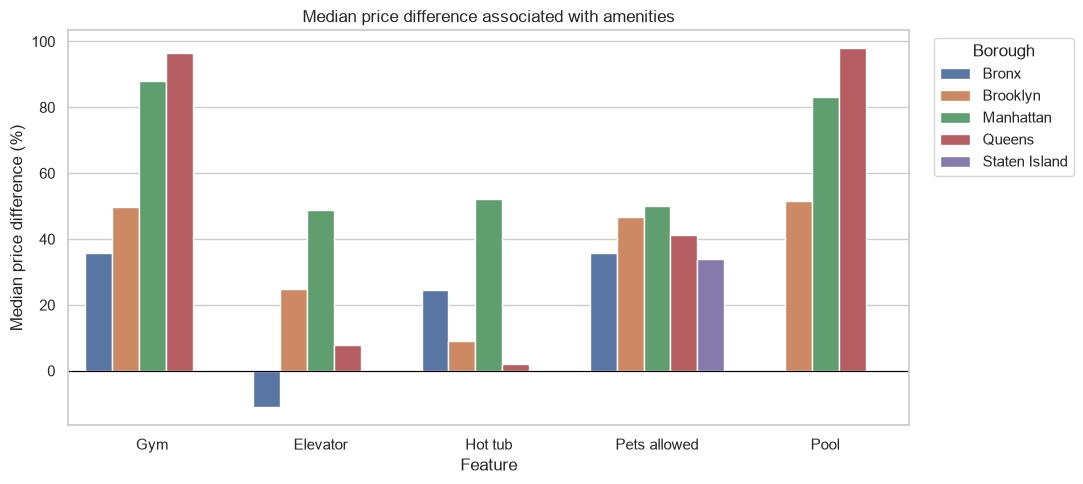

In [11]:
borough_feature = feature_summary.loc[
    feature_summary["scope"].isin(df["borough"].dropna().unique())
    & feature_summary["with_feature"].ge(20)
]

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=borough_feature,
    x="feature",
    y="median_premium_pct",
    hue="scope",
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(
    title="Median price difference associated with amenities",
    xlabel="Feature",
    ylabel="Median price difference (%)",
)
ax.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

**What I found.** Gym and Pool show the largest raw median price differences (about 119% and 121%). When I compare listings in the same borough and room type, the differences fall to about 44% and 45%, but remain the largest among the five features. Superhost listings cost more in Brooklyn and Queens but less in Manhattan. These are price differences in the data, not proof that the features caused them.

## 6. Timeline and Readiness Effect on Pricing

**How I compared them.** I grouped the next 30 days into no availability, limited availability, and readily available. Listing age runs from the first review to that listing's scrape date. I separated Manhattan and Brooklyn and also split listings by minimum stays below or above 30 nights.

Zero availability may mean fully booked, but it can also mean that the host blocked those dates.

In [12]:
READINESS_ORDER = [
    "Fully booked / no availability (0)",
    "Limited (1–14)",
    "Ready (15–30)",
]
MATURITY_ORDER = ["No reviews", "<1 year", "1–5 years", ">5 years"]
STAY_ORDER = ["Short-stay eligible", "30+ night minimum"]

scrape_dates = raw[["id", "last_scraped"]].copy()
scrape_dates["last_scraped"] = pd.to_datetime(
    scrape_dates["last_scraped"], errors="coerce"
)
q6 = priced.loc[priced["borough"].isin(BOROUGHS_MB)].merge(
    scrape_dates,
    on="id",
    how="left",
    validate="one_to_one",
)
q6["readiness"] = pd.cut(
    q6["availability_30"],
    bins=[-1, 0, 14, 30],
    labels=READINESS_ORDER,
)
q6["maturity_years"] = (
    q6["last_scraped"] - q6["first_review"]
).dt.days.div(365.25).clip(lower=0)
q6["maturity_band"] = pd.cut(
    q6["maturity_years"],
    bins=[-np.inf, 1, 5, np.inf],
    labels=["<1 year", "1–5 years", ">5 years"],
).astype("object")
q6["maturity_band"] = q6["maturity_band"].fillna("No reviews")
q6["stay_type"] = np.where(
    q6["minimum_nights"].lt(30),
    "Short-stay eligible",
    "30+ night minimum",
)

readiness_summary = q6.groupby(
    ["borough", "stay_type", "readiness"], observed=True
).agg(
    listings=("id", "size"),
    median_price=("price_usd", "median"),
).reset_index()

maturity_summary = q6.groupby(
    ["borough", "stay_type", "maturity_band"], observed=True
).agg(
    listings=("id", "size"),
    median_price=("price_usd", "median"),
).reset_index()

display(readiness_summary)
display(maturity_summary)
print(
    "Listing scrape dates:",
    q6["last_scraped"].min().date(),
    "to",
    q6["last_scraped"].max().date(),
)

,borough,stay_type,readiness,listings,median_price
0,Brooklyn,30+ night minimum,Fully booked / no availability (0),2114,110.47
1,Brooklyn,30+ night minimum,Limited (1–14),1294,115.86
2,Brooklyn,30+ night minimum,Ready (15–30),2337,149.60
3,Brooklyn,Short-stay eligible,Fully booked / no availability (0),108,275.34
4,Brooklyn,Short-stay eligible,Limited (1–14),860,257.00
5,Brooklyn,Short-stay eligible,Ready (15–30),526,279.50
6,Manhattan,30+ night minimum,Fully booked / no availability (0),3169,171.47
7,Manhattan,30+ night minimum,Limited (1–14),1489,193.60
8,Manhattan,30+ night minimum,Ready (15–30),2376,266.44
9,Manhattan,Short-stay eligible,Fully booked / no availability (0),208,497.00


,borough,stay_type,maturity_band,listings,median_price
0,Brooklyn,30+ night minimum,1–5 years,1968,132.74
1,Brooklyn,30+ night minimum,<1 year,387,94.81
2,Brooklyn,30+ night minimum,>5 years,1699,130.71
3,Brooklyn,30+ night minimum,No reviews,1691,125.00
4,Brooklyn,Short-stay eligible,1–5 years,849,260.25
5,Brooklyn,Short-stay eligible,<1 year,178,275.43
6,Brooklyn,Short-stay eligible,>5 years,395,259.00
7,Brooklyn,Short-stay eligible,No reviews,72,377.12
8,Manhattan,30+ night minimum,1–5 years,2148,186.65
9,Manhattan,30+ night minimum,<1 year,574,174.35


Listing scrape dates: 2026-06-14 to 2026-06-23


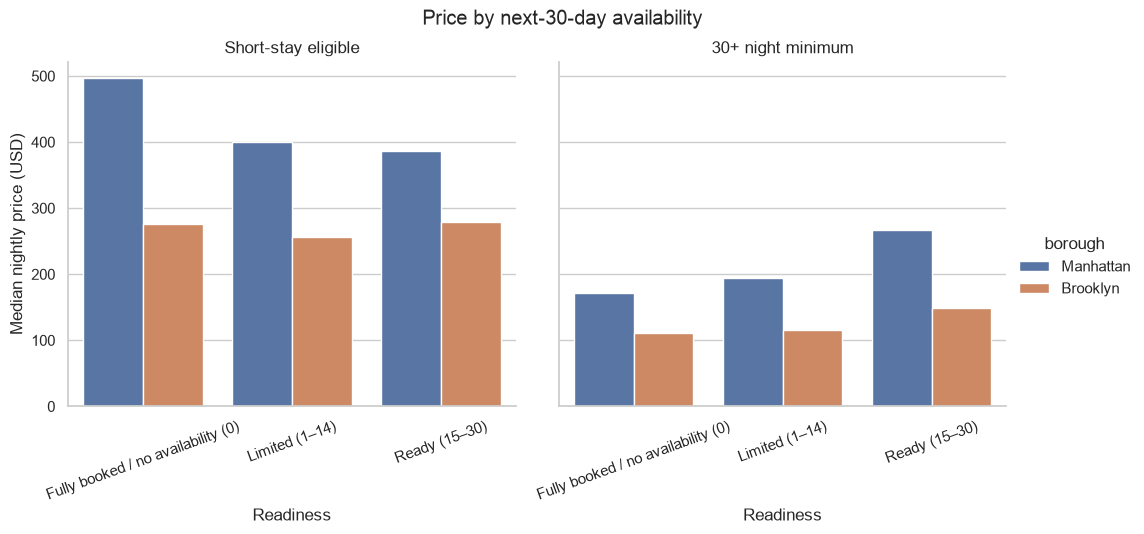

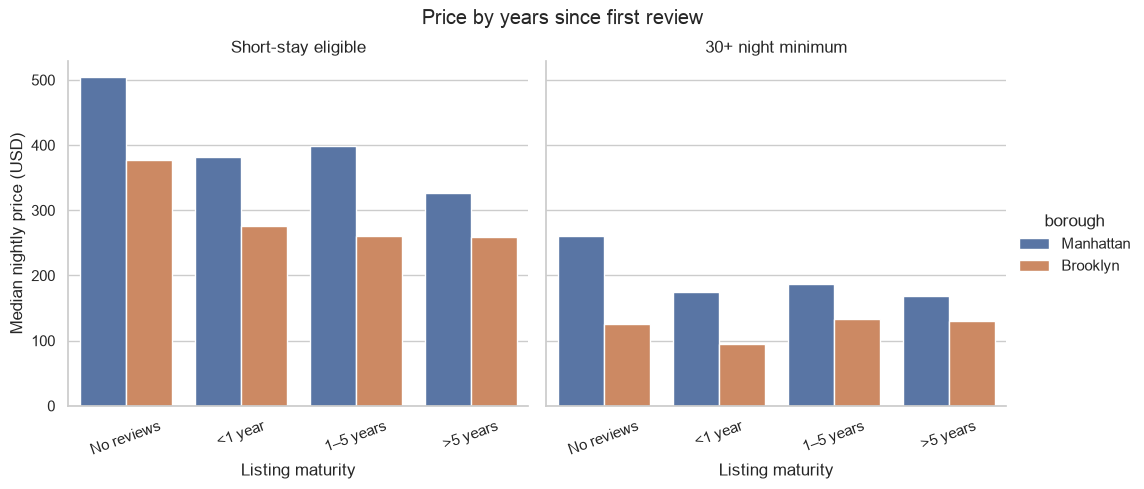

In [13]:
g = sns.catplot(
    data=readiness_summary,
    x="readiness",
    y="median_price",
    hue="borough",
    hue_order=BOROUGHS_MB,
    col="stay_type",
    col_order=STAY_ORDER,
    order=READINESS_ORDER,
    kind="bar",
    height=4.5,
    aspect=1.15,
)
g.set_axis_labels("Readiness", "Median nightly price (USD)")
g.set_titles("{col_name}")
g.figure.suptitle("Price by next-30-day availability", y=1.03)
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)
plt.show()

h = sns.catplot(
    data=maturity_summary,
    x="maturity_band",
    y="median_price",
    hue="borough",
    hue_order=BOROUGHS_MB,
    col="stay_type",
    col_order=STAY_ORDER,
    order=MATURITY_ORDER,
    kind="bar",
    height=4.5,
    aspect=1.15,
)
h.set_axis_labels("Listing maturity", "Median nightly price (USD)")
h.set_titles("{col_name}")
h.figure.suptitle("Price by years since first review", y=1.03)
for ax in h.axes.flat:
    ax.tick_params(axis="x", rotation=20)
plt.show()

**What I found.** For 30+ night listings, readily available homes are more expensive than listings with no availability in both boroughs (Brooklyn: about $150 vs $110; Manhattan: $266 vs $171). Short-stay prices are higher overall, but price does not rise consistently with 30-day availability. Older listings are not always more expensive, and unreviewed listings are often costly, so listing age alone does not explain price.

## 7. Host (“Developer”) Impact

**How I compared them.** I used `calculated_host_listings_count` as the assignment's measure of how many listings a host manages. I checked the results once per listing and once per host so that a few very large hosts did not dominate the comparison.

In [14]:
PORTFOLIO_ORDER = ["1", "2–5", "6–20", "21+"]
PORTFOLIO_BINS = [0, 1, 5, 20, np.inf]

for frame in (df, priced):
    frame["portfolio_group"] = pd.cut(
        frame["calculated_host_listings_count"],
        bins=PORTFOLIO_BINS,
        labels=PORTFOLIO_ORDER,
    )

portfolio_features = df.groupby("portfolio_group", observed=True).agg(
    listings=("id", "size"),
    unique_hosts=("host_id", "nunique"),
    median_amenities=("amenity_count", "median"),
    main_room_type=("room_type", top_values),
    main_property_type=("property_type", top_values),
)

priced["is_premium"] = priced["price_tier"].eq("Premium")
portfolio_prices = priced.groupby("portfolio_group", observed=True).agg(
    priced_listings=("id", "size"),
    median_price=("price_usd", "median"),
    premium_share=("is_premium", "mean"),
)
portfolio_prices["premium_share"] *= 100
listing_portfolio = portfolio_features.join(portfolio_prices, how="left")
room_mix_by_portfolio = pd.crosstab(
    df["portfolio_group"], df["room_type"], normalize="index"
).mul(100).reindex(PORTFOLIO_ORDER)

host_features = df.groupby("host_id").agg(
    host_name=("host_name", "first"),
    portfolio_size=("calculated_host_listings_count", "first"),
    observed_listings=("id", "size"),
    median_amenities=("amenity_count", "median"),
)
host_prices = priced.groupby("host_id").agg(
    priced_listings=("id", "size"),
    median_price=("price_usd", "median"),
    premium_share=("is_premium", "mean"),
)
host_level = host_features.join(host_prices, how="left").reset_index()
host_level["priced_listings"] = host_level["priced_listings"].fillna(0).astype(int)
host_level["price_coverage_pct"] = (
    host_level["priced_listings"].div(host_level["observed_listings"]).mul(100)
)
host_level["premium_share"] *= 100
host_level["portfolio_group"] = pd.cut(
    host_level["portfolio_size"],
    bins=PORTFOLIO_BINS,
    labels=PORTFOLIO_ORDER,
)

host_portfolio = host_level.groupby("portfolio_group", observed=True).agg(
    hosts=("host_id", "size"),
    hosts_with_price=("priced_listings", lambda s: s.gt(0).sum()),
    median_host_price=("median_price", "median"),
    median_host_amenities=("median_amenities", "median"),
    mean_host_premium_share=("premium_share", "mean"),
)

largest_hosts = host_level.sort_values(
    ["portfolio_size", "observed_listings"], ascending=False
).head(8)[
    [
        "host_id",
        "host_name",
        "portfolio_size",
        "observed_listings",
        "priced_listings",
        "price_coverage_pct",
        "median_price",
        "median_amenities",
        "premium_share",
    ]
]

display(listing_portfolio)
display(room_mix_by_portfolio)
display(host_portfolio)
display(largest_hosts)

,listings,unique_hosts,median_amenities,main_room_type,main_property_type,priced_listings,median_price,premium_share
portfolio_group,,,,,,,,
1,13274,13274,26.00,Entire home/apt,Entire rental unit,7794,173.36,30.63
2–5,6904,2711,30.00,Private room,Entire rental unit,5688,146.86,25.86
6–20,3739,405,29.00,Private room,Entire rental unit,3371,187.50,39.45
21+,6342,84,29.00,Entire home/apt,Entire rental unit,4662,220.00,42.56


room_type,Entire home/apt,Hotel room,Private room,Shared room
portfolio_group,,,,
1,61.87,0.01,37.49,0.64
2–5,43.97,0.29,55.14,0.59
6–20,39.53,3.72,56.06,0.70
21+,64.36,5.68,28.92,1.04


,hosts,hosts_with_price,median_host_price,median_host_amenities,mean_host_premium_share
portfolio_group,,,,,
1,13274,7794,173.36,26.00,30.63
2–5,2711,2330,150.47,30.00,25.47
6–20,405,384,192.02,29.00,40.85
21+,84,81,224.08,27.50,41.97


,host_id,host_name,portfolio_size,observed_listings,priced_listings,price_coverage_pct,median_price,median_amenities,premium_share
9892,107434423,Blueground,955,955,40,4.19,423.41,32.00,97.50
14073,446820235,Luxury Bookings Fze,331,331,331,100.00,538.61,43.00,99.70
8246,51501835,Jeniffer,262,262,261,99.62,165.93,15.00,12.26
5406,19303369,Hiroki,239,239,84,35.15,51.45,8.00,0.00
10910,162280872,Urban Furnished,231,231,230,99.57,247.59,35.00,50.00
7128,35491667,LEAP NY Apartments,217,217,201,92.63,65.89,22.00,0.00
14516,476218709,Kristina,214,214,214,100.00,106.59,11.00,0.00
11411,200239515,Shogo,212,212,77,36.32,49.80,9.00,0.00


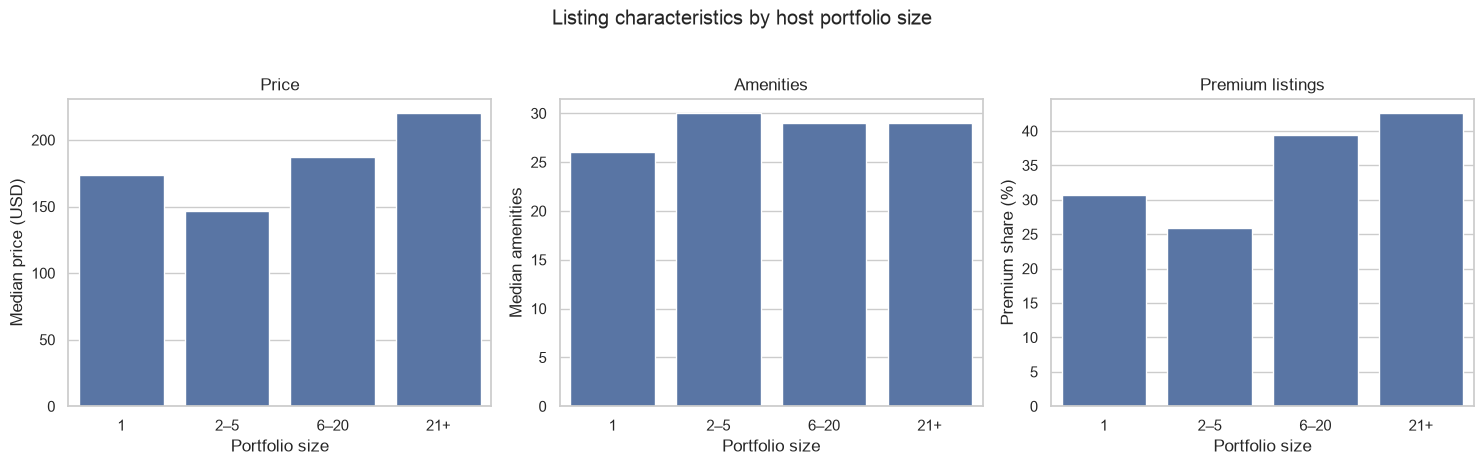

In [15]:
portfolio_plot = listing_portfolio.reset_index()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.barplot(
    data=portfolio_plot,
    x="portfolio_group",
    y="median_price",
    order=PORTFOLIO_ORDER,
    ax=axes[0],
)
axes[0].set(title="Price", xlabel="Portfolio size", ylabel="Median price (USD)")

sns.barplot(
    data=portfolio_plot,
    x="portfolio_group",
    y="median_amenities",
    order=PORTFOLIO_ORDER,
    ax=axes[1],
)
axes[1].set(title="Amenities", xlabel="Portfolio size", ylabel="Median amenities")

sns.barplot(
    data=portfolio_plot,
    x="portfolio_group",
    y="premium_share",
    order=PORTFOLIO_ORDER,
    ax=axes[2],
)
axes[2].set(title="Premium listings", xlabel="Portfolio size", ylabel="Premium share (%)")

fig.suptitle("Listing characteristics by host portfolio size", y=1.03)
plt.tight_layout()

**What I found.** Listings from portfolios of 21+ have the highest median price ($220) and premium-tier share (42.6%). Using all listings, their median amenity count is 29, so larger portfolios do not show a clear amenity advantage. Their mix is 64.4% entire homes and 5.7% hotel rooms, both higher than the middle portfolio groups. The same price pattern appears when each host is given equal weight, but price coverage varies widely among individual large hosts.

## Main takeaways

1. Premium listings are concentrated in Manhattan, while Budget listings are spread more widely.
2. Manhattan remains more expensive than Brooklyn after comparing the same room types.
3. Prime neighborhoods charge more per guest without equally large gains in space or amenities.
4. Queens offers the best value among the larger groups compared; the highest individual values still need checking.
5. Gym and Pool are linked to higher prices, but the difference changes by borough and listing type.
6. Availability and listing age do not have one simple relationship with price; short-stay eligibility matters more.
7. Large host portfolios contain more premium listings, but not clearly more amenities.

These patterns come from one market snapshot. They do not prove that location, features, or host size caused the price differences.